In [ ]:
#import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Make plots easier to read
sns.set_theme(style="whitegrid")

# Display more columns when inspecting data
pd.set_option("display.max_columns", None)


In [ ]:
#Load the datasets

winners_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-04-07/tdf_winners.csv"
stages_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-04-07/tdf_stages.csv"

winners = pd.read_csv(winners_url)
stages = pd.read_csv(stages_url)

print("Winners dataset shape:", winners.shape)
print("Stages dataset shape:", stages.shape)


Winners dataset shape: (106, 19)
Stages dataset shape: (2236, 8)


In [5]:
print("WINNERS DATASET")
display(winners.head())

print("\nSTAGES DATASET")
display(stages.head())


WINNERS DATASET


,edition,start_date,winner_name,winner_team,distance,time_overall,time_margin,stage_wins,stages_led,height,weight,age,born,died,full_name,nickname,birth_town,birth_country,nationality
0,1,1903-07-01,Maurice Garin,La Française,2428.0,94.553889,2.989167,3,6,1.62,60.0,32,1871-03-03,1957-02-19,NaN,The Little Chimney-sweep,Arvier,Italy,France
1,2,1904-07-02,Henri Cornet,Conte,2428.0,96.098611,2.270556,1,3,NaN,NaN,19,1884-08-04,1941-03-18,NaN,Le rigolo (The joker),Desvres,France,France
2,3,1905-07-09,Louis Trousselier,Peugeot–Wolber,2994.0,NaN,NaN,5,10,NaN,NaN,24,1881-06-29,1939-04-24,NaN,Levaloy / Trou-trou,Paris,France,France
3,4,1906-07-04,René Pottier,Peugeot–Wolber,4637.0,NaN,NaN,5,12,NaN,NaN,27,1879-06-05,1907-01-25,NaN,NaN,Moret-sur-Loing,France,France
4,5,1907-07-08,Lucien Petit-Breton,Peugeot–Wolber,4488.0,NaN,NaN,2,5,NaN,NaN,24,1882-10-18,1917-12-20,Lucien Georges Mazan,Lucien Petit-Breton,Plessé,France,France



STAGES DATASET


,Stage,Date,Distance,Origin,Destination,Type,Winner,Winner_Country
0,1,2017-07-01,14.0,Düsseldorf,Düsseldorf,Individual time trial,Geraint Thomas,GBR
1,2,2017-07-02,203.5,Düsseldorf,Liège,Flat stage,Marcel Kittel,GER
2,3,2017-07-03,212.5,Verviers,Longwy,Medium mountain stage,Peter Sagan,SVK
3,4,2017-07-04,207.5,Mondorf-les-Bains,Vittel,Flat stage,Arnaud Démare,FRA
4,5,2017-07-05,160.5,Vittel,La Planche des Belles Filles,Medium mountain stage,Fabio Aru,ITA


## 3. Inspect and clean the winners dataset

In [6]:
winners.info()


<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   edition        106 non-null    int64  
 1   start_date     106 non-null    str    
 2   winner_name    106 non-null    str    
 3   winner_team    106 non-null    str    
 4   distance       106 non-null    float64
 5   time_overall   98 non-null     float64
 6   time_margin    98 non-null     float64
 7   stage_wins     106 non-null    int64  
 8   stages_led     106 non-null    int64  
 9   height         66 non-null     float64
 10  weight         67 non-null     float64
 11  age            106 non-null    int64  
 12  born           106 non-null    str    
 13  died           56 non-null     str    
 14  full_name      46 non-null     str    
 15  nickname       74 non-null     str    
 16  birth_town     106 non-null    str    
 17  birth_country  106 non-null    str    
 18  nationality    106 no

In [7]:
# Check missing values
missing_values = winners.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])


full_name       60
died            50
height          40
weight          39
nickname        32
time_overall     8
time_margin      8
dtype: int64

In [8]:
# Convert the start date to datetime and create the Tour edition year
winners["start_date"] = pd.to_datetime(winners["start_date"])
winners["year"] = winners["start_date"].dt.year

# Check the important variables
important_columns = [
    "year",
    "winner_name",
    "nationality",
    "age",
    "stages_led",
    "time_overall",
    "time_margin"
]

display(winners[important_columns].head(10))


,year,winner_name,nationality,age,stages_led,time_overall,time_margin
0,1903,Maurice Garin,France,32,6,94.553889,2.989167
1,1904,Henri Cornet,France,19,3,96.098611,2.270556
2,1905,Louis Trousselier,France,24,10,NaN,NaN
3,1906,René Pottier,France,27,12,NaN,NaN
4,1907,Lucien Petit-Breton,France,24,5,NaN,NaN
5,1908,Lucien Petit-Breton,France,25,13,NaN,NaN
6,1909,François Faber,Luxembourg,22,13,NaN,NaN
7,1910,Octave Lapize,France,22,3,NaN,NaN
8,1911,Gustave Garrigou,France,26,13,NaN,NaN
9,1912,Odile Defraye,Belgium,23,13,NaN,NaN


In [9]:
#winning time and runnerup

time_df = winners.dropna(
    subset=["time_overall", "time_margin"]
).copy()

print("Number of editions with complete winning-time data:", len(time_df))
print("Years covered:", time_df["year"].min(), "to", time_df["year"].max())


Number of editions with complete winning-time data: 98
Years covered: 1903 to 2019


In [10]:
# Summary statistics for winning time
winning_time_summary = time_df["time_overall"].describe()

display(winning_time_summary)


count     98.000000
mean     125.754983
std       41.559391
min       82.086667
25%       92.601597
50%      115.026806
75%      142.678472
max      238.740278
Name: time_overall, dtype: float64

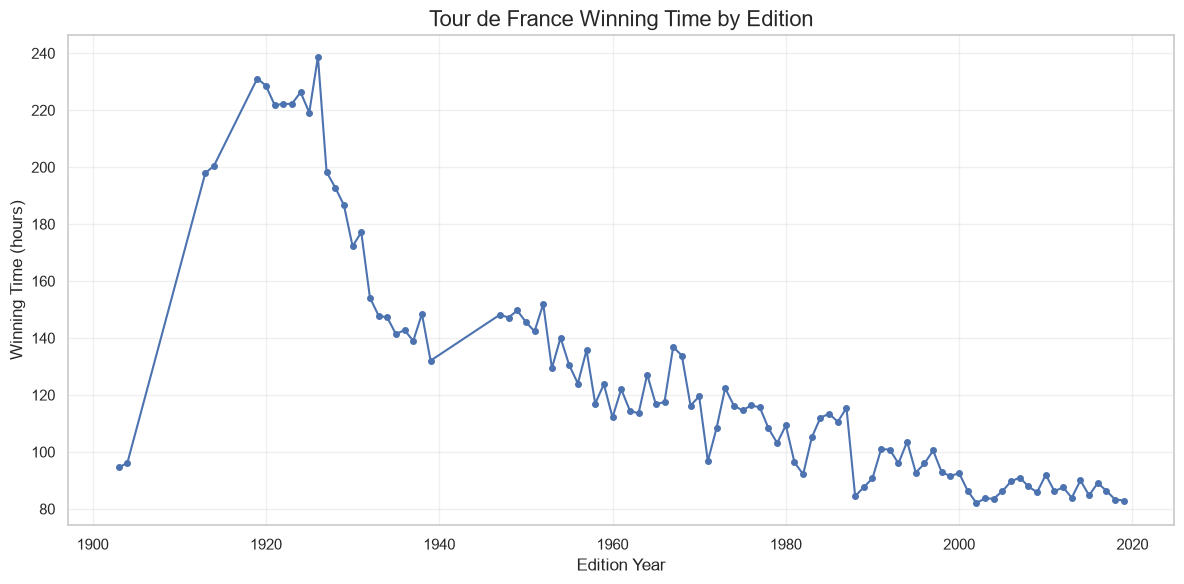

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    time_df["year"],
    time_df["time_overall"],
    marker="o",
    markersize=4,
    linewidth=1.5
)

plt.title("Tour de France Winning Time by Edition", fontsize=16)
plt.xlabel("Edition Year")
plt.ylabel("Winning Time (hours)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


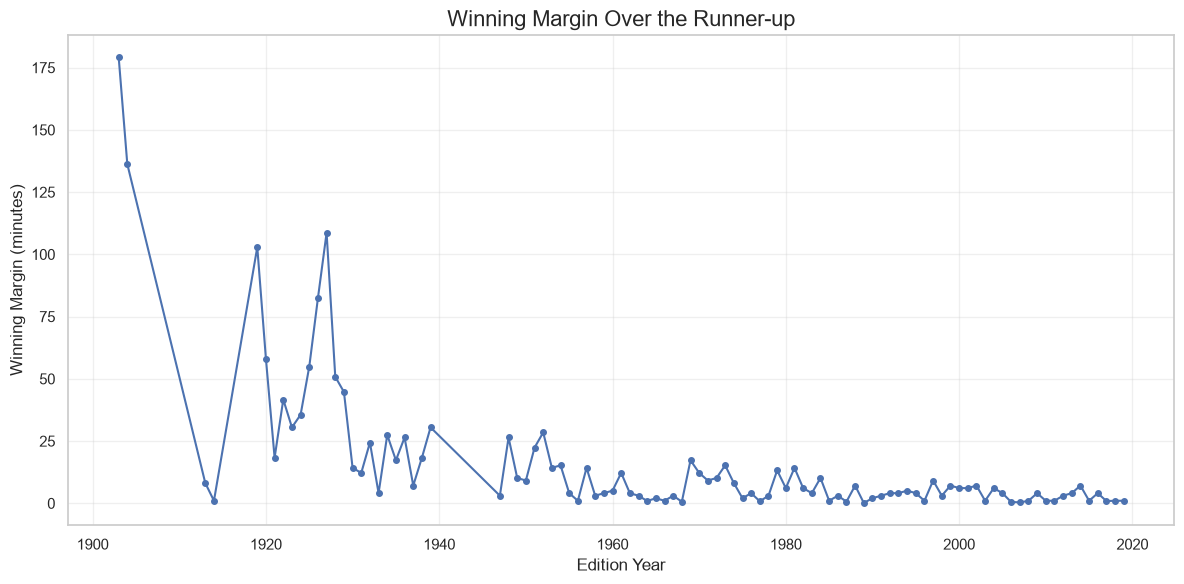

In [12]:
# Convert the winning margin from hours to minutes
time_df["margin_minutes"] = time_df["time_margin"] * 60

plt.figure(figsize=(12, 6))

plt.plot(
    time_df["year"],
    time_df["margin_minutes"],
    marker="o",
    markersize=4,
    linewidth=1.5
)

plt.title("Winning Margin Over the Runner-up", fontsize=16)
plt.xlabel("Edition Year")
plt.ylabel("Winning Margin (minutes)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
print("Smallest winning margin:")
display(time_df.loc[
    time_df["time_margin"].idxmin(),
    ["year", "winner_name", "time_margin", "margin_minutes"]
])

print("\nLargest winning margin:")
display(time_df.loc[
    time_df["time_margin"].idxmax(),
    ["year", "winner_name", "time_margin", "margin_minutes"]
])


Smallest winning margin:


year                     1989
winner_name       Greg LeMond
time_margin          0.002222
margin_minutes       0.133333
Name: 75, dtype: object


Largest winning margin:


year                       1903
winner_name       Maurice Garin
time_margin            2.989167
margin_minutes           179.35
Name: 0, dtype: object

In [14]:
time_df["period"] = pd.cut(
    time_df["year"],
    bins=[1900, 1939, 1959, 1979, 1999, 2019],
    labels=[
        "1913–1939",
        "1947–1959",
        "1960–1979",
        "1980–1999",
        "2000–2019"
    ]
)

period_summary = time_df.groupby(
    "period",
    observed=True
).agg(
    average_winning_time=("time_overall", "mean"),
    median_winning_margin=("margin_minutes", "median")
)

display(period_summary)


,average_winning_time,median_winning_margin
period,,
1913–1939,179.172456,30.500000
1947–1959,137.343675,10.166667
1960–1979,116.596750,4.066667
1980–1999,99.614875,4.066667
2000–2019,86.748833,2.033333


In [15]:
early_average = period_summary.loc["1913–1939", "average_winning_time"]
modern_average = period_summary.loc["2000–2019", "average_winning_time"]

percentage_reduction = (
    (early_average - modern_average) / early_average
) * 100

print(f"Average winning time, 1913–1939: {early_average:.2f} hours")
print(f"Average winning time, 2000–2019: {modern_average:.2f} hours")
print(f"Reduction in average winning time: {percentage_reduction:.1f}%")


Average winning time, 1913–1939: 179.17 hours
Average winning time, 2000–2019: 86.75 hours
Reduction in average winning time: 51.6%


In [16]:
stages.info()


<class 'pandas.DataFrame'>
RangeIndex: 2236 entries, 0 to 2235
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Stage           2236 non-null   str    
 1   Date            2236 non-null   str    
 2   Distance        2236 non-null   float64
 3   Origin          2236 non-null   str    
 4   Destination     2236 non-null   str    
 5   Type            2236 non-null   str    
 6   Winner          2236 non-null   str    
 7   Winner_Country  2184 non-null   str    
dtypes: float64(1), str(7)
memory usage: 139.9 KB


In [17]:
# Check missing values in the stage dataset
stage_missing = stages.isnull().sum().sort_values(ascending=False)
display(stage_missing[stage_missing > 0])


Winner_Country    52
dtype: int64

In [18]:
# Standardize the stage date and inspect stage types
stages["Date"] = pd.to_datetime(stages["Date"])
stages["year"] = stages["Date"].dt.year

print("Stage types:")
display(stages["Type"].value_counts())


Stage types:


Type
Plain stage                      1053
Stage with mountain(s)            530
Individual time trial             205
Flat stage                        110
Team time trial                    87
Hilly stage                        76
High mountain stage                43
Mountain stage                     40
Medium mountain stage              33
Mountain time trial                13
Mountain Stage                     11
Stage with mountain                11
Flat Stage                          9
Half Stage                          5
Transition stage                    4
Intermediate stage                  3
Flat cobblestone stage              2
Plain stage with cobblestones       1
Name: count, dtype: int64

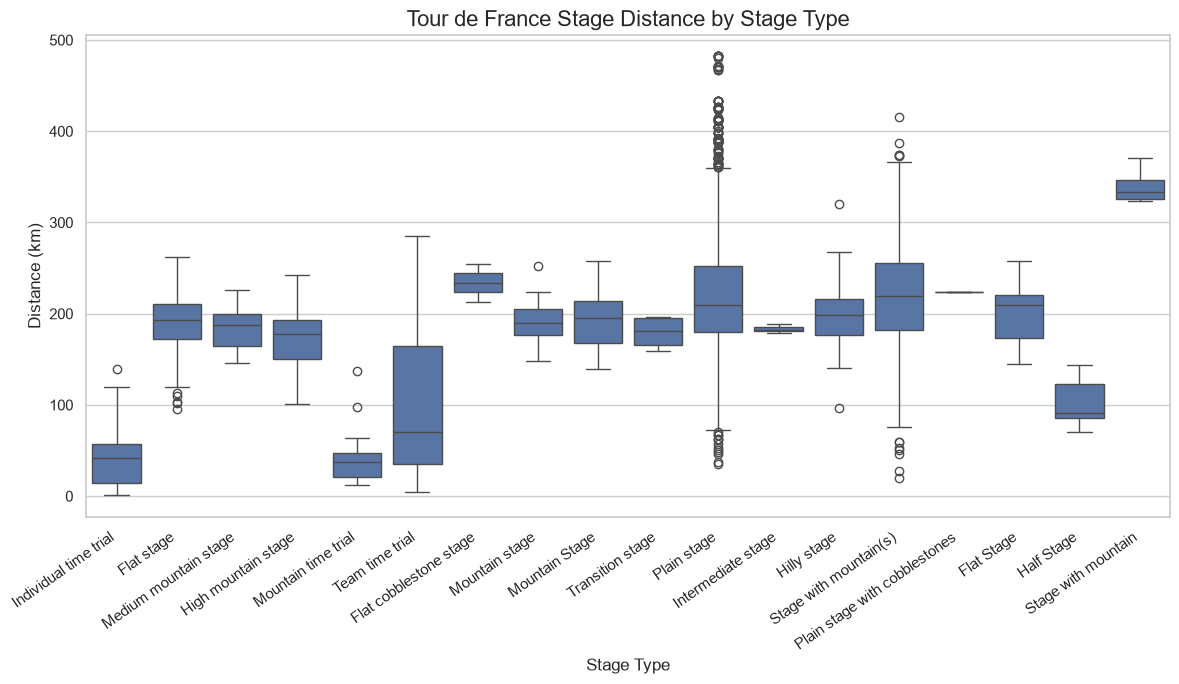

In [19]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=stages,
    x="Type",
    y="Distance"
)

plt.title("Tour de France Stage Distance by Stage Type", fontsize=16)
plt.xlabel("Stage Type")
plt.ylabel("Distance (km)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


In [20]:
stage_summary = stages.groupby("Type")["Distance"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median", ascending=False)

display(stage_summary)


,count,mean,median,min,max
Type,,,,,
Stage with mountain,11,337.818182,333.00,323.0,371.0
Flat cobblestone stage,2,234.000000,234.00,213.0,255.0
Plain stage with cobblestones,1,224.000000,224.00,224.0,224.0
Stage with mountain(s),530,220.900189,219.00,19.6,416.0
Plain stage,1053,226.270940,210.00,35.0,482.0
Flat Stage,9,202.222222,209.00,145.0,258.0
Hilly stage,76,196.328947,198.25,97.0,320.0
Mountain Stage,11,193.727273,195.00,139.0,258.0
Flat stage,110,189.609091,193.25,95.0,262.0


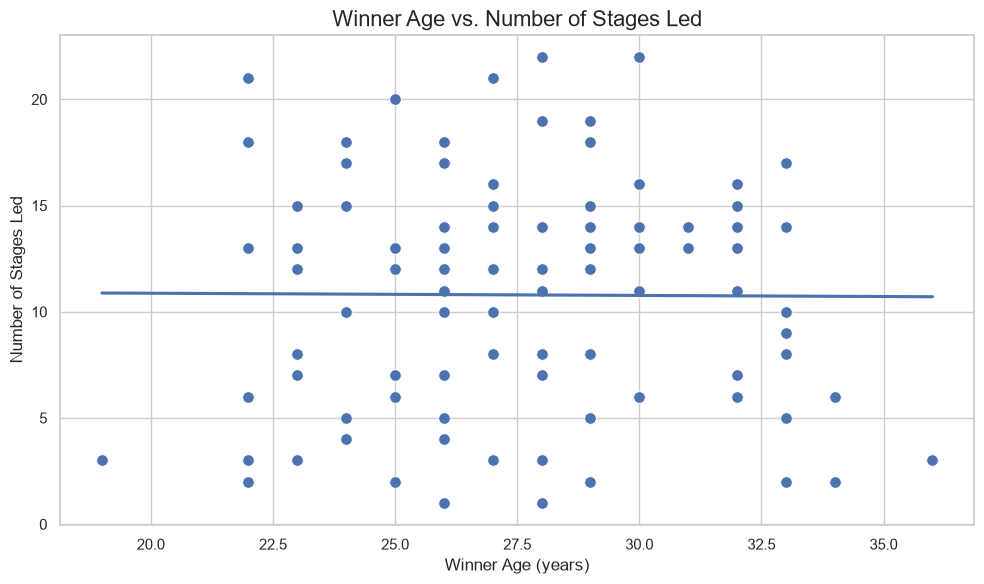

In [21]:
# Relationship between winner data
age_df = winners.dropna(
    subset=["age", "stages_led"]
).copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=age_df,
    x="age",
    y="stages_led",
    s=70
)

# Add a trend line
sns.regplot(
    data=age_df,
    x="age",
    y="stages_led",
    scatter=False,
    ci=None
)

plt.title("Winner Age vs. Number of Stages Led", fontsize=16)
plt.xlabel("Winner Age (years)")
plt.ylabel("Number of Stages Led")
plt.tight_layout()
plt.show()


In [22]:
pearson_r, pearson_p = pearsonr(
    age_df["age"],
    age_df["stages_led"]
)

spearman_rho, spearman_p = spearmanr(
    age_df["age"],
    age_df["stages_led"]
)

print(f"Pearson correlation: {pearson_r:.3f}")
print(f"Pearson p-value: {pearson_p:.3f}")
print(f"Spearman correlation: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.3f}")


Pearson correlation: -0.007
Pearson p-value: 0.947
Spearman correlation: 0.011
Spearman p-value: 0.913


In [23]:
#Most recent winner and nationality
recent_winner = winners.sort_values(
    "start_date",
    ascending=False
).iloc[0]

print("Most recent Tour edition:", recent_winner["year"])
print("Winner:", recent_winner["winner_name"])
print("Nationality:", recent_winner["nationality"])


Most recent Tour edition: 2019
Winner: Egan Bernal
Nationality:  Colombia


In [24]:
# Count wins by nationality
nationality_counts = (
    winners["nationality"]
    .str.strip()
    .value_counts()
)

display(nationality_counts.head(15))


nationality
France           36
Belgium          18
Spain            12
Italy            10
United States    10
Great Britain     6
Luxembourg        5
Switzerland       2
Netherlands       2
Ireland           1
Denmark           1
Germany           1
Australia         1
Colombia          1
Name: count, dtype: int64

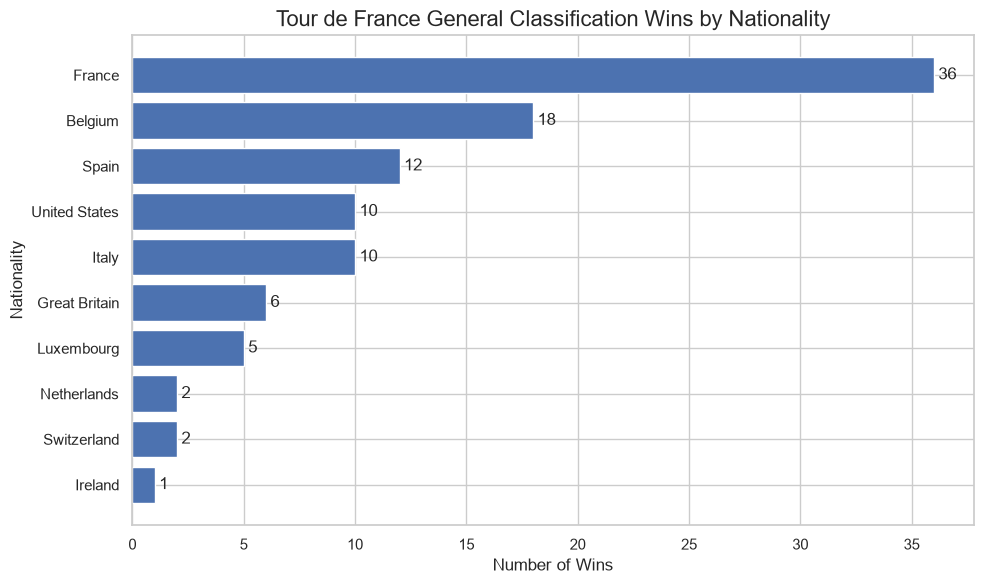

In [ ]:
top_nationalities = nationality_counts.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_nationalities.index
    top_nationalities.values
)

plt.title(
    "Tour de France General Classification Wins by Nationality",
    fontsize=16
)

plt.xlabel("Number of Wins")
plt.ylabel("Nationality")

for i, value in enumerate(top_nationalities.values):
    plt.text(
        value + 0.2,
        i,
        str(value),
        va="center"
    )

plt.tight_layout()
plt.show()


In [26]:
recent_winners = (
    winners.sort_values("year", ascending=False)
    [["year", "winner_name", "nationality"]]
    .head(10)
    .sort_values("year")
)

display(recent_winners)


,year,winner_name,nationality
96,2010,Andy Schleck,Luxembourg
97,2011,Cadel Evans,Australia
98,2012,Bradley Wiggins,Great Britain
99,2013,Chris Froome,Great Britain
100,2014,Vincenzo Nibali,Italy
101,2015,Chris Froome,Great Britain
102,2016,Chris Froome,Great Britain
103,2017,Chris Froome,Great Britain
104,2018,Geraint Thomas,Great Britain
105,2019,Egan Bernal,Colombia
